# Comparison between Tag–Model and Argo–Model Temperature Misfits

## Objective

This notebook compares temperature misfits between biologging tag observations and an ocean
reanalysis, and contrasts them with misfits derived independently from Argo float observations.

The objectives are:
- To evaluate whether tag–model temperature differences are consistent with the uncertainty
  diagnosed from Argo profiles.
- To assess the depth dependence of model–observation discrepancies.
- To test the Gaussianity of normalized temperature errors used in the geolocation likelihood.

This notebook complements the Argo-based variance estimation by validating its applicability
to biologging tag observations.

In [1]:
!jupyter nbconvert --to script test_of_kde.ipynb

[NbConvertApp] Converting notebook test_of_kde.ipynb to script
[NbConvertApp] Writing 19934 bytes to test_of_kde.py


## 1. Computational setup

A local Dask cluster is initialized to enable parallel processing.
This is required to efficiently handle large gridded model datasets
and repeated profile comparisons.

In [1]:
# Set up a local cluster for distributed computing.
from distributed import LocalCluster

cluster = LocalCluster()
client = cluster.get_client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 20,Total memory: 149.01 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35383,Workers: 5
Dashboard: http://127.0.0.1:8787/status,Total threads: 20
Started: Just now,Total memory: 149.01 GiB
Comm: tcp://127.0.0.1:36953,Total threads: 4
Dashboard: http://127.0.0.1:35385/status,Memory: 29.80 GiB
Nanny: tcp://127.0.0.1:33089,


## 2. Input data and study domain

This section defines:
- The biologging tag to be analyzed,
- The geographic bounding box,
- Storage access parameters for object storage,
- Required scientific Python libraries.

The spatial domain corresponds to the region explored by the tagged individual.

In [2]:
import sys

import hvplot.xarray
import xarray as xr
from pint_xarray import unit_registry as ureg

sys.path.append("../")

tag_root = "s3://gfts-ifremer/tuna_mediterranean/tags/formatted"
tag_name = "18P0430"

bbox = {"latitude": [16, 35], "longitude": [120, 145]}

storage_options = {
    "anon": False,
    "profile": "gfts",
    "client_kwargs": {
        "endpoint_url": "https://s3.gra.perf.cloud.ovh.net",
        "region_name": "gra",
    },
}


## 3. Loading biologging (DST) data

Biologging data recorded by the tag are loaded, including temperature and pressure
time series.

Tagging event metadata (release and recapture / fish death) are used to define
time windows for model–data comparison.

In [4]:
from pangeo_fish.helpers import load_tag, plot_tag
from pangeo_fish.io import open_tag
from pangeo_fish.tags import adapt_model_time, reshape_by_bins, to_time_slice

# Open and retrieve the tag data required for the analysis
tag = open_tag(tag_root, tag_name)
time_slice = to_time_slice(tag["tagging_events/time"])
tag_log = tag["dst"].ds.sel(time=time_slice)



/srv/conda/envs/notebook/lib/python3.12/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)


## 4. Ocean model data

Temperature fields from the Copernicus ocean reanalysis are loaded.
The model provides three-dimensional temperature fields on a fixed grid
and serves as the reference ocean state for comparison with observations.

In [5]:

import xarray as xr
from pangeo_fish.helpers import _open_parquet_model, load_model, prepare_dataset
# Open the previous dataset (only necessary if you resume the notebook from here)
model = xr.open_dataset(
    "s3://gfts-ifremer/tuna_mediterranean/run/capetienne//18P0430/model_variance.zarr",
    engine="zarr",
    chunks={},
    storage_options=storage_options,
)
model

<xarray.Dataset> Size: 91GB
Dimensions:             (lat: 336, lon: 649, time: 368, depth: 141)
Coordinates:
  * depth               (depth) float32 564B 1.018 3.166 ... 5.646e+03 5.754e+03
  * lat                 (lat) float32 1kB 32.02 32.06 32.1 ... 45.9 45.94 45.98
    latitude            (lat, lon) float32 872kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * lon                 (lon) float32 3kB -6.0 -5.958 -5.917 ... 20.96 21.0
    longitude           (lat, lon) float32 872kB dask.array<chunksize=(100, 100), meta=np.ndarray>
  * time                (time) datetime64[ns] 3kB 2019-06-01 ... 2020-06-02
Data variables:
    H0                  (lat, lon) float32 872kB dask.array<chunksize=(100, 100), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float32 45GB dask.array<chunksize=(8, 20, 100, 100), meta=np.ndarray>
    XE                  (time, lat, lon) float32 321MB dask.array<chunksize=(8, 100, 100), meta=np.ndarray>
    dynamic_bathymetry  (lat, lon, time) float32 321MB dask.array<chunksize=(100, 100, 8), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float32 45GB dask.array<chunksize=(20, 8, 100, 100), meta=np.ndarray>
    mask                (depth, lat, lon) int8 31MB dask.array<chunksize=(20, 100, 100), meta=np.ndarray>
Attributes:
    references:   Escudier, R., Clementi, E., Omar, M., Cipollone, A., Pistoi...
    title:        Potential Temperature (3D) - Daily Mean
    institution:  Centro Euro-Mediterraneo sui Cambiamenti Climatici - CMCC, ...
    contact:      servicedesk.cmems@mercator-ocean.eu
    Conventions:  CF-1.0
    comment:      Please check in CMEMS catalogue the INFO section for produc...
    source:       MFS E3R1I

## 5. Utility functions and preprocessing

This section defines helper functions used throughout the notebook, including:
- Root-mean-square error (RMSE) computation,
- Vertical interpolation of model temperatures onto observed depths,
- Conversion between vertical coordinates when required.

These utilities ensure a consistent comparison framework between datasets.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import fsspec
import os
# Liste des tags à partir des dossiers disponibles
tags_list_raw = fsspec.filesystem("s3", **storage_options).ls(tag_root)
tags_list = [os.path.basename(p.rstrip("/")) for p in tags_list_raw if not p.endswith(".csv") and not p.endswith(".json")]

# Chargement des modèles Copernicus et JAMSTEC
ref_model_file = "../copernicus_ref_model/copernicus_jpn_daily_20220105.zarr/"
model_cop = model#prepare_dataset(xr.open_dataset(ref_model_file, engine="zarr", chunks={}, storage_options=None))

from sklearn.metrics import mean_squared_error

def compute_rmse(model_temp, model_depth, temp_tag, pres_tag):
    # Interpolation des températures du modèle sur les profondeurs observées
    temp_model_interp = np.interp(pres_tag, model_depth, model_temp)
    # Calcul de la RMSE
    rmse = np.sqrt(mean_squared_error(temp_tag, temp_model_interp))
    return rmse

# Fonction pour calculer profondeur dynamique pour JAMSTEC
def dsigma_to_depth(ds):
    depth = ds["el"] + ds["ZZ"]
    depth = depth.assign_attrs({"units": "m", "long_name": "Depth at layer centers"})
    return ds.assign(dynamic_depth=np.abs(depth.astype(np.float32)))


results = []

## 6. Visual comparison of tag profiles at release and recapture

For each valid tag, temperature–depth profiles observed by the tag are compared
to the model temperature profile at the release and recapture (or fish death) locations.

Observed tag temperatures are color-coded by elapsed time relative to the event,
allowing a qualitative assessment of short-term thermal variability.

<xarray.DataArray 'pressure' ()> Size: 8B
array(296.5)
<xarray.DataArray 'pressure' ()> Size: 8B
array(236.)


/tmp/ipykernel_4195/1443896940.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1])  # laisser espace à droite pour colorbars


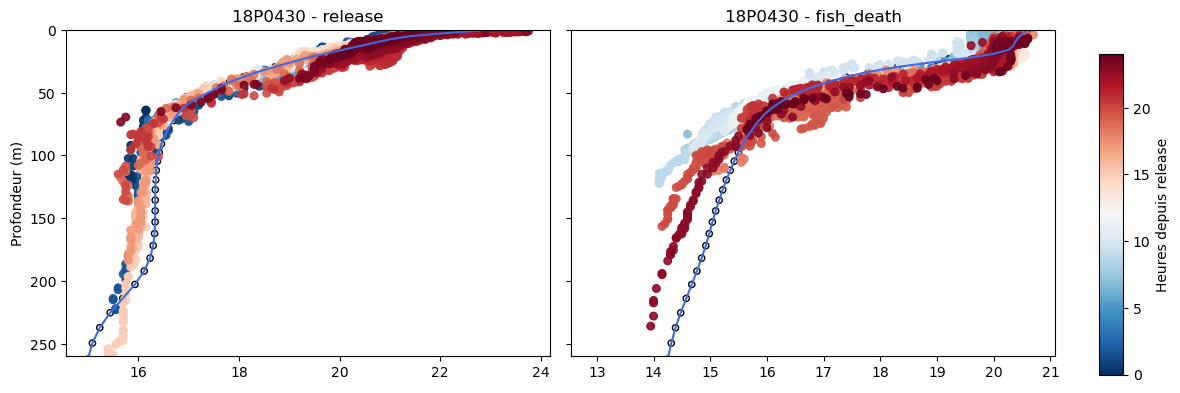

In [17]:
def plot_all_tags(tags_list):
    
    valid_tags = []
    for tag_name in tags_list:
        try:
            tag = open_tag(tag_root, tag_name, storage_options=storage_options)
            events = tag["tagging_events"]
            if "release" in events.event_name.values or "fish_death" in events.event_name.values:
                valid_tags.append(tag_name)
        except Exception as e:
            print(f"Erreur avec tag {tag_name} : {e}")


    n_tags = len(valid_tags)
    nrows, ncols = n_tags, 2  # ➤ 2 colonnes fixes (release / recapture)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), sharey=True)
    if nrows == 1:
        axes = np.array([axes])  # axes = 2D array always

    cmap = plt.cm.RdBu_r  # colormap globale

    for row_idx, tag_name in enumerate(valid_tags):
        try:
            tag = open_tag(tag_root, tag_name, storage_options=storage_options)
            events = tag["tagging_events"]
            dst = tag["dst"].ds

            for col_idx, evt in enumerate(["release", "fish_death"]):
                ax = axes[row_idx, col_idx]

                if evt not in events.event_name.values:
                    ax.set_title(f"{tag_name} - {evt}\n(données manquantes)")
                    ax.axis("off")
                    continue

                # --- Infos ---
                i = list(events.event_name.values).index(evt)
                lat = float(events.latitude.values[i])
                lon = float(events.longitude.values[i])
                time = pd.Timestamp(events.time.values[i])

                if evt == "release":
                    ds_tag = dst.sel(time=slice(time, time + pd.Timedelta("24h")))
                else:
                    ds_tag = dst.sel(time=slice(time - pd.Timedelta("24h"), time))
                
                # Model Copernicus
                point_cop = model_cop.sel(time=time, lat=lat, lon=lon, method="nearest")
                temp_cop = point_cop["TEMP"].compute()
                depth_cop = point_cop["dynamic_depth"].compute()

                # Tag data
                temp_tag = ds_tag["temperature"].compute()
                pres_tag = ds_tag["pressure"].compute()
                print(pres_tag.max())
                # --- Colormap temps ---
                time_tag = pd.to_datetime(ds_tag["time"].values)
                
                if evt == "release":
                    # 0 → 24 h
                    time_elapsed = (time_tag - time_tag[0]).total_seconds() / 3600  # heures
                    tmin, tmax = 0, 24
                else:  # recapture
                    # -48 → 0 h
                    time_elapsed = (time_tag - time_tag[-1]).total_seconds() / 3600  # heures négatives
                    tmin, tmax = -24, 0
                
                # Normalisation pour la colormap
                time_norm = (time_elapsed - tmin) / (tmax - tmin)  # ∈ [0,1]
                colors = cmap(time_norm)

                max_depth_obs = float(pres_tag.max())
                delta = 0.1 * max_depth_obs if max_depth_obs > 0 else 50

                # --- Tracé ---
                ax.plot(temp_cop, depth_cop, color='royalblue', label='Copernicus')
                ax.scatter(temp_cop, depth_cop, s=20, facecolors='none', edgecolors='black')
                ax.scatter(temp_tag, pres_tag, c=colors, s=30, alpha=0.9)

                ax.invert_yaxis()
                ax.set_ylim(max_depth_obs + delta, 0)
                ax.set_title(f"{tag_name} - {evt}")
                if col_idx == 0:
                    ax.set_ylabel("Profondeur (m)")

            # --- AJOUT D’UNE COLORBAR PAR TAG --- #
            # position dynamique basée sur la ligne correspondante
            y0 = 0.05 + (n_tags - row_idx - 1) / n_tags * 0.9   # haut/bas
            y1 = y0 + 0.8 / n_tags                               # hauteur

            cbar_ax = fig.add_axes([0.92, y0, 0.02, y1 - y0])     # [x, y, width, height]
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=24))
            fig.colorbar(sm, cax=cbar_ax, label="Heures depuis release")

        except Exception as e:
            print(f"Erreur avec tag {tag_name} : {e}")

    plt.tight_layout(rect=[0, 0, 0.90, 1])  # laisser espace à droite pour colorbars
    plt.show()

tags_list = ["18P0430"]
plot_all_tags(tags_list)

## 7. Supporting functions for variance diagnostics

This section defines functions used to:
- Compute two-dimensional histograms of temperature misfits versus depth,
- Estimate depth-dependent variance,
- Interpolate variance or standard deviation onto arbitrary depth axes.

These functions mirror those used in the Argo-only variance analysis.

In [8]:
import numpy as np
import xarray as xr
from scipy.interpolate import interp1d


def variance_interp_function(yedges, var):
    depth_centers = 0.5 * (yedges[:-1] + yedges[1:])
    f_var = interp1d(
        depth_centers, var, bounds_error=False, fill_value=(var[0], var[-1])
    )
    return f_var


def compute_hist2d(results, nbins_diff=50, nbins_depth=1000, max_depth=None):
    all_diff = np.concatenate([r["diff"] for r in results]) if results else np.array([])
    all_pres = np.concatenate([r["pres"] for r in results]) if results else np.array([])

    mask = np.isfinite(all_diff) & np.isfinite(all_pres)
    all_diff, all_pres = all_diff[mask], all_pres[mask]

    if all_diff.size == 0:
        return None, None, None

    # Depth limit
    if max_depth is not None:
        depth_mask = all_pres <= max_depth
        all_diff, all_pres = all_diff[depth_mask], all_pres[depth_mask]

    dmin, dmax = np.nanpercentile(all_diff, [1, 99])
    dmax_abs = max(abs(dmin), abs(dmax))
    diff_bins = np.linspace(-dmax_abs, dmax_abs, nbins_diff + 1)
    depth_bins = np.linspace(
        0,
        max_depth if max_depth is not None else np.nanpercentile(all_pres, 98),
        nbins_depth + 1,
    )

    counts, xedges, yedges = np.histogram2d(
        all_diff, all_pres, bins=[diff_bins, depth_bins]
    )
    return counts, xedges, yedges


def variance_by_depth(counts, xedges):
    """
    Computes the weighted variance of ΔT for each row (depth)
    from the 2D histogram.
    """
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])

    weights_sum = counts.sum(axis=0)

    weights_sum[weights_sum == 0] = np.nan

    mean = np.nansum(counts * xcenters[:, None], axis=0) / weights_sum

    var = np.nansum(counts * (xcenters[:, None] - mean) ** 2, axis=0) / weights_sum

    var_norm = var / np.nanmax(var)

    return var, var_norm
def std_interp_function(yedges, var):
    depth_centers = 0.5 * (yedges[:-1] + yedges[1:])
    std = np.sqrt(var)
    f_std = interp1d(
        depth_centers, std, bounds_error=False, fill_value=(std[0], std[-1])
    )
    return f_std


## 8. Loading Argo-based misfit statistics

Previously computed Argo–model temperature misfits are loaded.
These data provide an independent estimate of depth-dependent model uncertainty
against which tag–model misfits can be compared.

In [9]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

with open("results_copernicus_medit_smallbbox.pkl", "rb") as f:
    results_copernicus = pickle.load(f)



## 9. Tag–model temperature misfit computation

For each tagging event (release and recapture), temperature profiles measured by the tag
are compared to the nearest model grid point in space and time.

Model temperatures are interpolated onto the tag pressure levels, and pointwise
temperature differences are computed as:
$$
\Delta T(z) = T_{\mathrm{model}}(z) - T_{\mathrm{tag}}(z)
$$

In addition, a root-mean-square error (RMSE) is computed for each profile comparison.

In [ ]:
def compute_pointwise_diffs(model_temp, model_depth, temp_tag, pres_tag):
    # interpolation du modèle sur les profondeurs observées
    temp_model_interp = np.interp(pres_tag, model_depth, model_temp, left=np.nan, right=np.nan)
    diff = temp_model_interp - temp_tag   # 🔹 point par point !
    return diff, temp_model_interp
def compute_rmse(model_temp, model_depth, temp_tag, pres_tag):

    # 🔥 1. On enlève les niveaux modèle NaN
    valid_model = np.isfinite(model_temp) & np.isfinite(model_depth)

    model_temp = model_temp[valid_model]
    model_depth = model_depth[valid_model]

    # sécurité si profil vide
    if len(model_temp) < 2:
        return np.nan

    # 🔥 2. Interpolation propre
    temp_model_interp = np.interp(
        pres_tag,
        model_depth,
        model_temp,
        left=np.nan,
        right=np.nan
    )

    # 🔥 3. Masque points comparables
    mask = np.isfinite(temp_model_interp) & np.isfinite(temp_tag)

    if mask.sum() == 0:
        return np.nan

    return np.sqrt(np.mean((temp_model_interp[mask] - temp_tag[mask])**2))

### 9.1 Event-based profile comparison

For each tag and each relevant event:
- A time window around the event is selected (±24–48 h),
- The nearest model profile is extracted,
- Temperature misfits are computed at each observed depth.

Both profile-level (RMSE) and pointwise misfits are stored for later analysis.

In [ ]:
def plot_profile_comparison(tag_id, event_type, time, lat, lon, tag_ds, results):
    point_cop = model_cop.sel(time=time, lat=lat, lon=lon, method="nearest")

    temp_cop = point_cop["TEMP"].compute()
    depth_cop = point_cop["dynamic_depth"].compute()
 
    print("ha")
    temp_tag = tag_ds["temperature"].compute()
    pres_tag = tag_ds["pressure"].compute()

    # On a souvent (time, depth) → on aplatit tout pour l’instant
    temp_tag_vals = np.ravel(temp_tag.values)
    pres_tag_vals = np.ravel(pres_tag.values)
    print("before rmse")
    # 💡 Calcul RMSE (modèle interpolé sur les pressions tag)
    rmse_cop = compute_rmse(temp_cop.values, depth_cop.values, temp_tag_vals, pres_tag_vals)

    temp_tag = tag_ds["temperature"].compute()
    pres_tag = tag_ds["pressure"].compute()
    
    temp_tag_vals = np.ravel(temp_tag.values)
    pres_tag_vals = np.ravel(pres_tag.values)
    
    mean_depth = float(np.nanmean(pres_tag_vals))
    max_depth  = float(np.nanmax(pres_tag_vals))

    results.append({
        "tag": tag_id,
        "event": event_type,
        "date": time.date(),
        "lat": lat,
        "lon": lon,
        "mean_depth": mean_depth,
        "max_depth": max_depth,
        "RMSE_Copernicus": rmse_cop,
    })
    #Différences point à point
    diff_cop, _ = compute_pointwise_diffs(temp_cop.values, depth_cop.values, temp_tag_vals, pres_tag_vals)
  
    # Ajout dans results POINT PAR POINT 🔥
    for z, d in zip(pres_tag_vals, diff_cop):
        results.append({
            "tag": tag_id,
            "event": event_type,
            "lat": lat,
            "lon": lon,
            "depth": z,
            "diff_cop": d,      # erreur T_mod - T_tag
        })

    # (tu peux garder la partie plotting si tu veux, je ne la répète pas ici)
results = []

for tag_name in tags_list:
    try:
        tag = open_tag(tag_root, tag_name, storage_options=storage_options)
        events = tag["tagging_events"]
        dst = tag["dst"].ds

        for evt in ["release", "fish_death"]:
            if evt in events.event_name:
                i = list(events.event_name.values).index(evt)
                lat = float(events.latitude.values[i])
                lon = float(events.longitude.values[i])
                time = pd.Timestamp(events.time.values[i])
                print(f"Tag {tag_name} – {evt}: {lat}, {lon} @ {time}")

                if evt == "release":
                    ds_tag = dst.sel(time=slice(time, time + pd.Timedelta("24h")))
                else:
                    ds_tag = dst.sel(time=slice(time - pd.Timedelta("24h"), time))

                plot_profile_comparison(tag_name, evt, time, lat, lon, ds_tag, results)

    except Exception as e:
        print(f"Erreur avec tag {tag_name} : {e}")
df_rmse = pd.DataFrame(results)

Tag 18P0430 – release: 35.0, 15.51667 @ 2019-06-08 16:00:00
ha
before rmse
[22.784418 22.04988  21.395859 21.00174  20.71063  20.406822 20.063147
 19.701025 19.355274 19.035082 18.710058 18.38614  18.089571 17.807367
 17.56368  17.342878 17.105055 16.916153 16.794113 16.69537  16.60314
 16.525496 16.459993 16.414133 16.379679 16.356987 16.343426 16.33637
 16.33392  16.334494 16.33264  16.32196  16.295242 16.233318 16.116692
 15.932392 15.690693 15.440172 15.233767 15.087729 14.998587       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
       nan       nan       nan       nan       nan       nan       nan
    

## 10. Aggregation of pointwise temperature misfits

All pointwise temperature differences across tags and events are aggregated
into a single dataset.

Each entry corresponds to one observed depth level and one temperature misfit,
allowing robust statistical analysis as a function of depth.

In [12]:

df_points = pd.DataFrame(results)
df_points = df_points.dropna(subset=["diff_cop", "depth"])  # nettoyage



df_points["diff_abs"] = np.abs(df_points["diff_cop"])


## 11. Incorporation of Argo-derived variance

Argo-based temperature misfit statistics are reintroduced to provide
a reference depth-dependent variance.

This allows direct comparison between:
- Variability inferred from Argo float profiles,
- Variability observed in tag–model temperature differences.

In [13]:
results = []  # stocke tous les points tous tags confondus

def variance_interp_function(yedges, var):
    depth_centers = 0.5 * (yedges[:-1] + yedges[1:])
    f_var = interp1d(
        depth_centers, var, bounds_error=False, fill_value=(var[0], var[-1])
    )
    return f_var
    
import numba
import numpy as np
import xarray as xr

def interp_var_at_depth(var_depth, var_values, tag_depth):
    from scipy.interpolate import interp1d
    interp = interp1d(
        var_depth,           # profondeur bin (centres)
        var_values,          # variance associée
        bounds_error=False,
        fill_value=(var_values[0], var_values[-1]),
        axis=-1,
    )
    return interp(tag_depth)   # profondeur cible (profil Argo typiquement)

def plot_profile_comparison(tag_id, event_type, time, lat, lon, tag_ds, results):
    point_cop = model_cop.sel(time=time, lat=lat, lon=lon, method="nearest")

    temp_cop  = point_cop["TEMP"].compute()
    depth_cop = point_cop["dynamic_depth"].compute()

    temp_tag = tag_ds["temperature"].compute()
    pres_tag = tag_ds["pressure"].compute()

    temp_tag_vals = np.ravel(temp_tag.values)
    pres_tag_vals = np.ravel(pres_tag.values)

    diff_cop, _ = compute_pointwise_diffs(
        temp_cop.values, depth_cop.values, temp_tag_vals, pres_tag_vals
    )

    for z, d in zip(pres_tag_vals, diff_cop):
        results.append({"depth": z, "diff": d})
for tag_name in tags_list:
    try:
        tag = open_tag(tag_root, tag_name, storage_options=storage_options)
        events = tag["tagging_events"]
        dst = tag["dst"].ds

        for evt in ["release", "fish_death"]:
            if evt in events.event_name:
                i = list(events.event_name.values).index(evt)
                lat = float(events.latitude.values[i])
                lon = float(events.longitude.values[i])
                time = pd.Timestamp(events.time.values[i])

                if evt == "release":
                    ds_tag = dst.sel(time=slice(time, time + pd.Timedelta("24h")))
                else:
                    ds_tag = dst.sel(time=slice(time - pd.Timedelta("48h"), time))

                plot_profile_comparison(tag_name, evt, time, lat, lon, ds_tag, results)

    except Exception as e:
        print(f"Erreur avec {tag_name} : {e}")

df_points = pd.DataFrame(results).dropna()


### 12.1 Vertical structure of temperature variance

This figure compares the vertical structure of temperature misfit variance
derived from Argo floats and from biologging tags.

Consistency between the two supports the use of Argo-derived variance
to normalize tag–model misfits.

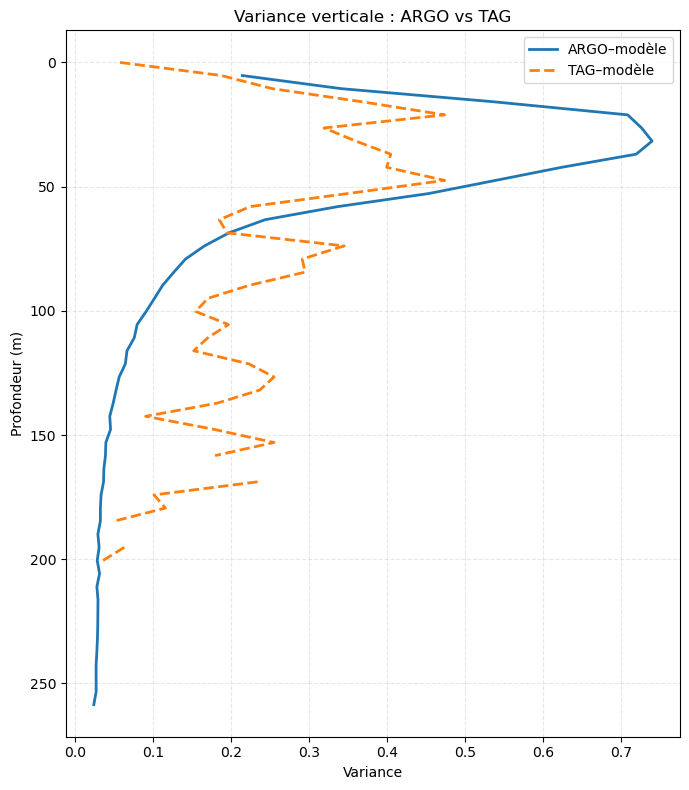

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ================================
# 1️⃣ VARIANCE DIRECTE TAG–MODÈLE
# ================================

df_points = pd.DataFrame(results).dropna()

diff_values  = df_points["diff"].to_numpy()
depth_values = df_points["depth"].to_numpy()
all_diff = np.concatenate([r["diff"] for r in results_copernicus])
all_pres = np.concatenate([r["pres"] for r in results_copernicus])


zmax = min(df_points["depth"].max(), all_pres.max())
depth_bins = np.linspace(0, zmax, 200)

depth_centers = 0.5 * (depth_bins[:-1] + depth_bins[1:])
depth_idx = np.digitize(depth_values, depth_bins)

var_tags = np.array([
    np.nanvar(diff_values[depth_idx == i]) if np.sum(depth_idx == i) > 1 else np.nan
    for i in range(1, len(depth_bins))
])

# ================================
# 2️⃣ VARIANCE DIRECTE ARGO–MODÈLE
# ================================


idx_argo = np.digitize(all_pres, depth_bins)

var_argo = np.array([
    np.nanvar(all_diff[idx_argo == i]) if np.sum(idx_argo == i) > 1 else np.nan
    for i in range(1, len(depth_bins))
])

# ================================
# 3️⃣ INTERPOLATION SUR AXE COMMUN
# ================================
depths_common = np.linspace(0, zmax, 50)

f_tags = interp1d(depth_centers, var_tags, bounds_error=False, fill_value="extrapolate")
f_argo = interp1d(depth_centers, var_argo, bounds_error=False, fill_value="extrapolate")

var_tags_i = f_tags(depths_common)
var_argo_i = f_argo(depths_common)

# ================================
# 4️⃣ PLOT
# ================================

plt.figure(figsize=(7,8))
plt.plot(var_argo_i, depths_common, label="ARGO–modèle", linewidth=2)
plt.plot(var_tags_i, depths_common, "--", label="TAG–modèle", linewidth=2)

plt.gca().invert_yaxis()
plt.xlabel("Variance")
plt.ylabel("Profondeur (m)")
plt.title("Variance verticale : ARGO vs TAG")
plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()


In [15]:
df_points["depth"].to_numpy().max()

np.float64(258.5)

## 13. Normalized error diagnostics

Tag–model temperature errors are normalized by the expected Argo-derived variance
at the corresponding depth:

$$
R(z) =
\frac{\Delta T(z)^2}{\mathrm{Var}_{\mathrm{ARGO}}(z)}
$$

The distribution and cumulative distribution function (CDF) of this ratio
are analyzed to assess whether observed errors are consistent with expected variance.

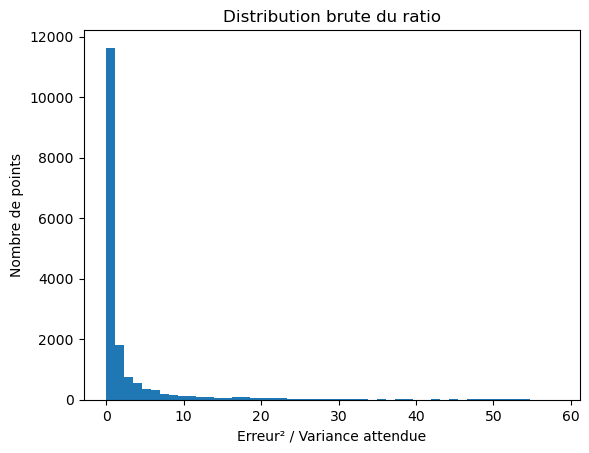

In [18]:
from scipy.interpolate import interp1d

f_var = interp1d(
    depth_centers,
    var_argo,
    bounds_error=False,
    fill_value="extrapolate"
)

ratio = (df_points["diff"]**2) / f_var(df_points["depth"])
ratio = ratio.dropna()
plt.hist(ratio, bins=50, density=False)
plt.xlabel("Erreur² / Variance attendue")
plt.ylabel("Nombre de points")
plt.title("Distribution brute du ratio")
plt.show()


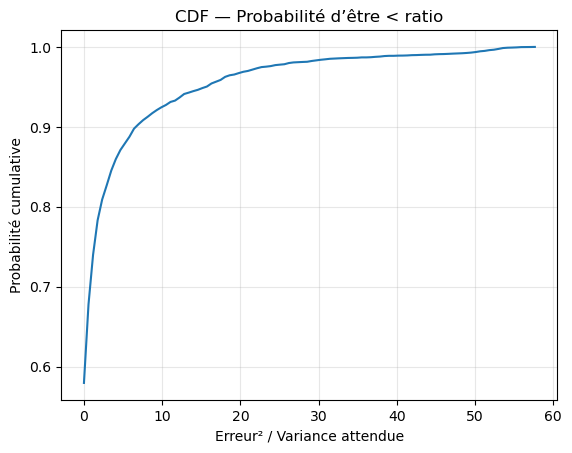

In [19]:
counts, edges = np.histogram(ratio, bins=100, density=True)
cdf = np.cumsum(counts) / np.sum(counts)

plt.plot(edges[:-1], cdf)
plt.xlabel("Erreur² / Variance attendue")
plt.ylabel("Probabilité cumulative")
plt.title("CDF — Probabilité d’être < ratio")
plt.grid(alpha=0.3)
plt.show()


## 14. Normalized error distribution and Gaussianity test

Normalized temperature errors are defined as:

$$
\varepsilon(z) =
\frac{T_{\mathrm{model}}(z) - T_{\mathrm{tag}}(z)}
{\sqrt{\mathrm{Var}_{\mathrm{ARGO}}(z)}}
$$

If the Argo-derived variance fully captures model uncertainty,
\(\varepsilon\) would follow a standard normal distribution.

This hypothesis is tested using:
- Visual comparison with a Gaussian distribution,
- A Kolmogorov–Smirnov statistical test,
- Kernel density estimation of the empirical distribution.

In [20]:
diff_values = df_points["diff"].to_numpy()       # T_mod - T_tag
depth_values = df_points["depth"].to_numpy()     # Profondeur de chaque point

sigma2_at_points = f_var(depth_values)     # Variance ARGO à la profondeur du tag
sigma_at_points = np.sqrt(sigma2_at_points)  # écart type (sqrt)
epsilon = diff_values / sigma_at_points
epsilon

array([-0.31037257, -0.18913226, -0.05681902, ...,  0.23500603,
        0.25311275,  0.16121141])

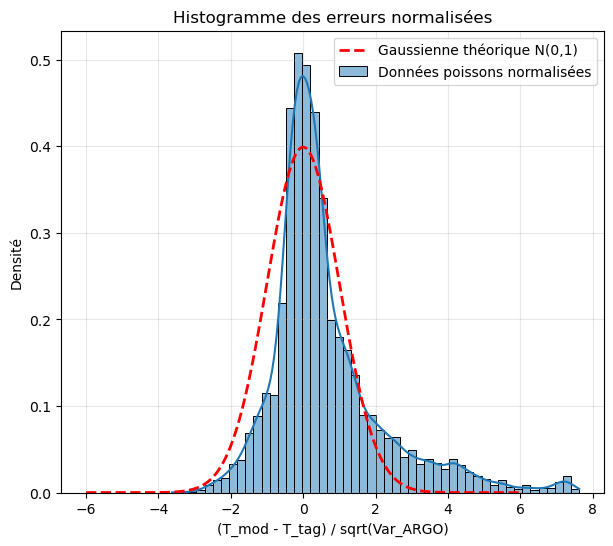

Test KS → stat=nan, p-value=nan


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, kstest



plt.figure(figsize=(7,6))
sns.histplot(epsilon, bins=50, kde=True, stat="density", label="Données poissons normalisées")

# Superposition distribution N(0,1)
x = np.linspace(-6, 6, 200)
plt.plot(x, norm.pdf(x), 'r--', linewidth=2, label="Gaussienne théorique N(0,1)")

plt.xlabel("(T_mod - T_tag) / sqrt(Var_ARGO)")
plt.ylabel("Densité")
plt.title("Histogramme des erreurs normalisées")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Test statistique KS
stat, pvalue = kstest(epsilon, 'norm')
print(f"Test KS → stat={stat:.3f}, p-value={pvalue:.3e}")
